# Sistema de suspensión del auto
<img src="https://drive.google.com/uc?export=view&id=13o8BWFvNQ3hMZKUs45B40p7HkKt78cm9" width="400">


Sistema de ecuaciones:
$$\"z_2 +\frac{k_1}{M}z_2 + \frac{c}{M}\.z_2-\frac{k_1}{M}z_1-\frac{c}{M}\.z_1 = g\$$
$$\"z_1 +\frac{k_1+k_2}{m}z_1 + \frac{c}{m}\.z_1-\frac{k_1}{m}z_2-\frac{c}{m}\.z_2 = g+\frac{k_2}{m}r$$

Parámetros:  
M = 300 kg      
m = 40 kg       
k1 = 18000N/m --> constante elástica de la suspensión       
c = 1500 Ns/m --> amortiguador      
k2 = 180 000 N/m --> rigidez del neumático      




In [39]:
# importar modulos
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
M = 300
m = 40
k1 = 18000
c = 1500
k2 = 180000
g = 9.81

# simulacion tiempo
h = 0.001
tsim = 5
# Crear vector tiempo
t = np.arange(0,tsim+h,h)

# otra forma de hacerlo 
n = int((tsim -  0)/h)+1
t_otro = np.linspace(0,tsim,n)

# Función de entrada
def r(t):
    salida = 0
    return salida
# Funciòn a resolver
def sistema(t,x):
    x0 = x[0]
    x1 = x[1]
    x2 = x[2]
    x3 = x[3]

    dx0 = x1
    dx2 = x3
    dx3 = - k1/M*x2 - c/M*x3 + k1/M*x0 + c/M*x1 + g
    dx1 = - (k1+k2)/m*x0 - c/m*x1 + k1/m*x2 + c/m*x3 + g + k2/m*r(t)
    return np.array([dx0,dx1,dx2,dx3])

# Condiciones iniciales
x0_0 = 0
x1_0 = 0
x2_0 = 0
x3_0 = 0

def rk4(f,t,x_iniciales):
    n = len(t)
    h = t[1] - t[0]
    x_sol = np.zeros((4,n))
    x_sol[:,0] = x_iniciales
    for i in range(n-1):
        k1 = f(t[i],x_sol[:,i])
        k2 = f(t[i]+h/2,x_sol[:,i]+h*k1/2)
        k3 = f(t[i]+h/2,x_sol[:,i]+h*k2/2)
        k4 = f(t[i]+h,x_sol[:,i]+h*k3)

        x_sol[:,i+1] = x_sol[:,i] + h*(k1+2*k2+2*k3+k4)/6

    return x_sol
a = rk4(sistema,t,[x0_0,x1_0,x2_0,x3_0])

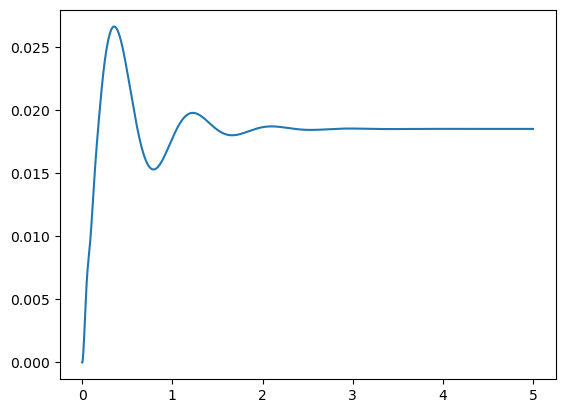

In [41]:
plt.plot(t,a[0])
